## Export all media from the results

### NOTE!

This Notebook has to be run on the [PAWS service](https://www.mediawiki.org/wiki/Manual:Pywikibot/PAWS)

You have to 
* upload the results files
* download the gzipped results

This notebook effectively prepares a nice result table for the paper

In [1]:
import pandas as pd
from PIL import Image
from io import BytesIO
import tqdm
import requests

In [2]:
print("Test")

Test


In [3]:
img_name="Plastiki_hull_closeup.jpg"

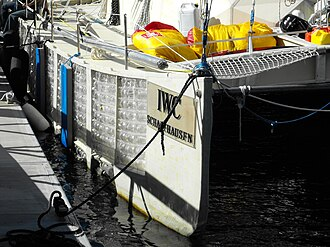

In [4]:
Image.open(BytesIO(requests.get(f"https://commons.wikimedia.org/wiki/Special:FilePath/{img_name}?width=330", headers={"User-Agent": "Qlever Image Viewer/1.0"}).content))

In [5]:
easy_results = pd.read_csv("dbpedia_easy_results.csv")
hard_results = pd.read_csv("dbpedia_hard_results.csv")
easy_results

FileNotFoundError: [Errno 2] No such file or directory: 'dbpedia_easy_results.csv'

In [ ]:
import time
def thumbs_to_pil(thumbs: pd.Series):

    pil_images = []
    g = tqdm.tqdm(thumbs, desc="Fetching thumbnails")
    for thumb in g:
        g.set_description(f"Fetching thumbnail for {thumb}...")
        # url_thumb = get_wc_thumb(thumb)
        thumb_url = f"https://commons.wikimedia.org/wiki/Special:FilePath/{thumb.split('/')[-1]}?width=330"
        try:
            response = None
            while response is None or response.status_code == 429:  # Too Many Requests
                response = requests.get(
                    thumb_url,
                    headers={"User-Agent": "Qlever Image Viewer/1.0"},
                )
                if response.status_code == 429:
                    waiting_time = response.headers.get("Retry-After", 5)
                    print(
                        f"Rate limited when fetching {thumb_url}, retrying after {waiting_time} seconds..."
                    )
                    time.sleep(int(waiting_time))
            img = Image.open(BytesIO(response.content))
            pil_images.append(img)
        except Exception as e:
            print(f"Error loading image {thumb_url}: {e}")
            pil_images.append(None)
    return pd.Series(pil_images, index=thumbs.index)

In [ ]:
easy_results["thumb_img"] = thumbs_to_pil(easy_results["thumb"])
hard_results["thumb_s_img"] = thumbs_to_pil(hard_results["thumb_s"])
hard_results["thumb_r_img"] = thumbs_to_pil(hard_results["thumb_r"])

Fetching thumbnail for https://upload.wikimedia.org/wikipedia/commons/2/22/Gorch_FockI_Schriftzug.jpg...: 100%|██████████| 10/10 [00:01<00:00,  5.70it/s]            
Fetching thumbnail for http://upload.wikimedia.org/wikipedia/commons/a/ac/USS_North_Dakota_%28SSN-784%29_at_sea_in_August_2014.JPG...: 100%|██████████| 20/20 [00:03<00:00,  6.47it/s]
Fetching thumbnail for http://upload.wikimedia.org/wikipedia/commons/2/2c/Sea_Beach_Line.png...: 100%|██████████| 20/20 [00:03<00:00,  6.30it/s]                                                                                                 


In [ ]:
hard_results

,r,s,dist,thumb_rail_emb,thumb_ship_emb,thumb_s,thumb_r,thumb_s_img,thumb_r_img
0,dbr:Chengdu_Metro,dbr:Virginia-class_submarine,149.755585,"{""data"": [0.22622749209403992, 0.0546034500002...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,dbr:Taipa_line,dbr:Virginia-class_submarine,148.544846,"{""data"": [0.03102342039346695, -0.059559382498...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.PngImagePlugin.PngImageFile image mode=RG...
2,dbr:Yangluo_Line,dbr:Virginia-class_submarine,146.525604,"{""data"": [0.13901150226593018, 0.1055586785078...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,dbr:Buenos_Aires_Underground,dbr:Virginia-class_submarine,140.403061,"{""data"": [-0.05835258960723877, -0.16195827722...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,http://upload.wikimedia.org/wikipedia/commons/...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,dbr:Line_13_(CPTM),dbr:Virginia-class_submarine,139.579163,"{""data"": [-0.21847796440124512, -0.04886087775...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
5,dbr:Kolkata_Metro,dbr:I-201-class_submarine,139.080490,"{""data"": [-0.0022863298654556274, -0.211197406...","{""data"": [0.0012263432145118713, -0.0422745048...",https://upload.wikimedia.org/wikipedia/commons...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
6,dbr:Orlyval,dbr:Virginia-class_submarine,138.492188,"{""data"": [0.11910116672515869, -0.394591093063...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
7,dbr:Abbey_Line,dbr:Virginia-class_submarine,138.049683,"{""data"": [0.18120601773262024, -0.300545185804...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
8,dbr:London_Overground,dbr:Virginia-class_submarine,137.636429,"{""data"": [0.02959146350622177, 0.0380432158708...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,https://upload.wikimedia.org/wikipedia/commons...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
9,dbr:CDGVAL,dbr:Virginia-class_submarine,135.493790,"{""data"": [-0.1729656457901001, 0.0039286464452...","{""data"": [-0.10002894699573517, -0.08042059838...",http://upload.wikimedia.org/wikipedia/commons/...,http://upload.wikimedia.org/wikipedia/commons/...,<PIL.JpegImagePlugin.JpegImageFile image mode=...,<PIL.JpegImagePlugin.JpegImageFile image mode=...


In [ ]:
from pathlib import Path

In [ ]:
out_path = Path("out")
out_path.mkdir(exist_ok=True)

In [ ]:
#out_path = Path("./results/")


def to_tex_with_thumbs(
    df,
    t_cols=["thumb_img"],
    index_cols=[ "Railway", "Ship",],
    col_mapping={
        "s": "Ship",
        "r": "Railway",
        "thumb_img_tex": "Image",
        "thumb_r_img_tex": "Image Railway",
        "thumb_s_img_tex": "Image Ship",
        "dist": "Distance",
    },
    base_dir="figures/generated",
    sub_dir="dbpedia/media",
    out_name="dbpedia_easy_results.tex",
    col_format ="lcr",
    k=10,
):
    df = df[:k].copy()
    out_path.mkdir(parents=True, exist_ok=True)
    results_dir = Path(out_path) / sub_dir
    results_dir.mkdir(parents=True, exist_ok=True)
    fig_dir = Path(base_dir) / sub_dir
    for t_col in t_cols:
        df[f"{t_col}_tex"] = df[t_col]
        for i, r in df.iterrows():
            if r[t_col] is not None and isinstance(r[t_col], Image.Image):
                fname = f"{t_col}_{i}.png"
                fig_file = fig_dir / fname
                im_file = results_dir / fname
                df.at[i, f"{t_col}_tex"] = f"\\padfig{{\\includegraphics[height=2em, width=3em, keepaspectratio]{{{fig_file}}}}}"
                print(f"Saving image for row {i} to {im_file} and referencing as {fig_file} in LaTeX", r[t_col])
                img: Image = r[t_col]
                img.save(im_file)
            else:
                df.at[i, f"{t_col}_tex"] = "No image"
    df_renamed = df.rename(columns=col_mapping)
    print(f"Renamed columns for LaTeX: {df_renamed.columns}")
    allowed_cols = [c for c in list(col_mapping.values()) if c in df_renamed.columns]
    print(f"Allowed columns for LaTeX output: {allowed_cols}")
    df_renamed = df_renamed[allowed_cols]
    index_allowed_cols = [c for c in index_cols if c in df_renamed.columns]
    df_renamed[index_allowed_cols] = df_renamed[index_allowed_cols].map(lambda s: f'\\texttt{{{s.replace("_","\\_")}}}')
    df_renamed.set_index(index_allowed_cols, inplace=True)
    df_renamed.style.to_latex(
        buf= results_dir / out_name,
        column_format=col_format,
        clines="all;data",
        hrules=True,
    )


to_tex_with_thumbs(easy_results)
to_tex_with_thumbs(hard_results, 
    t_cols=["thumb_s_img", "thumb_r_img"], out_name="dbpedia_hard_results.tex", col_format= 'rrccl')

Saving image for row 0 to out/dbpedia/media/thumb_img_0.png and referencing as figures/generated/dbpedia/media/thumb_img_0.png in LaTeX <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=330x247 at 0x7FB3FCC6FCB0>
Saving image for row 1 to out/dbpedia/media/thumb_img_1.png and referencing as figures/generated/dbpedia/media/thumb_img_1.png in LaTeX <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=330x217 at 0x7FB3FCC35280>
Saving image for row 2 to out/dbpedia/media/thumb_img_2.png and referencing as figures/generated/dbpedia/media/thumb_img_2.png in LaTeX <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=330x250 at 0x7FB3FCC341A0>
Saving image for row 3 to out/dbpedia/media/thumb_img_3.png and referencing as figures/generated/dbpedia/media/thumb_img_3.png in LaTeX <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=330x168 at 0x7FB3FCC037D0>
Saving image for row 4 to out/dbpedia/media/thumb_img_4.png and referencing as figures/generated/dbpedia/media/thumb_img_4.png in

In [ ]:
import tarfile

with tarfile.open("out.tar.gz", "w|gz",) as tar:
    for f in out_path.rglob('*'):
        tar.add(f)